In [ ]:
# matching test

import json, os, re
from pathlib import Path

SEQ_ROOT = Path.home() / "Desktop/YOLOv5-6D-Pose/data/sequences/flying"

# 1) JSONs are at flying/flying/{k}/sequence.json
json_root = SEQ_ROOT / "flying"
json_keys = {}
for d in sorted(json_root.iterdir()):
    seq_json = d / "sequence.json"
    if seq_json.exists():
        with open(seq_json) as f:
            data = json.load(f)
        k = list(data.keys())[0]
        N = len(data[k]["t"])
        json_keys[k] = {"folder": d.name, "N": N, "level": data[k].get("level"), "arena": data[k].get("arena")}

# 2) Image folders at flying/trajectory_{tid}_{suffix}/drone/images/
img_folders = {}
pat = re.compile(r"trajectory_(\d+)_(\d+)")
for d in sorted(SEQ_ROOT.iterdir()):
    m = pat.match(d.name)
    if m and (d / "drone" / "images").exists():
        tid = m.group(1)
        suffix = m.group(2)
        n_imgs = len(list((d / "drone" / "images").glob("*")))
        img_folders[tid] = {"folder": d.name, "suffix": suffix, "n_imgs": n_imgs}

# 3) Cross-check
print(f"JSON entries: {len(json_keys)}  |  Image folders: {len(img_folders)}")
print(f"\n{'key':>5}  {'N_json':>6}  {'N_imgs':>6}  {'match':>5}  {'img_folder':<30}  {'level':>5}  {'arena':>5}")
print("-" * 85)

matched, mismatched, missing = 0, 0, 0
for k in sorted(json_keys.keys(), key=int):
    jk = json_keys[k]
    if k in img_folders:
        ik = img_folders[k]
        ok = "✓" if jk["N"] == ik["n_imgs"] else f"✗"
        if jk["N"] == ik["n_imgs"]:
            matched += 1
        else:
            mismatched += 1
        print(f"{k:>5}  {jk['N']:>6}  {ik['n_imgs']:>6}  {ok:>5}  {ik['folder']:<30}  {jk['level']:>5}  {jk['arena']:>5}")
    else:
        missing += 1
        print(f"{k:>5}  {jk['N']:>6}  {'---':>6}  {'MISS':>5}  {'':30}  {jk['level']:>5}  {jk['arena']:>5}")

orphans = set(img_folders.keys()) - set(json_keys.keys())
print(f"\nMatched: {matched}  |  N mismatch: {mismatched}  |  Missing imgs: {missing}  |  Orphans: {len(orphans)}")
if mismatched > 0:
    print("\nMismatches:")
    for k in sorted(json_keys.keys(), key=int):
        if k in img_folders and json_keys[k]["N"] != img_folders[k]["n_imgs"]:
            print(f"  {k}: json={json_keys[k]['N']} imgs={img_folders[k]['n_imgs']}")

In [ ]:
# YOLO6D → PnP → WORLD-FRAME POSE — SINGLE RANDOM flying SEQUENCE
#
# PURPOSE:
#   Quick test: pick one random flying trajectory, run YOLO6D + PnP,
#   transform to world frame, print results. Same pipeline as full
#   pnp_flying.py but single-sequence for fast iteration.
#
# DIRECTORY LAYOUT:
#   flying/flying/{k}/sequence.json              — GT data
#   flying/trajectory_{k}_{suffix}/drone/images/  — rendered frames
#
# OUTPUT:
#   Console report only — no files saved.

import numpy as np, cv2, sys, json, re, random
from pathlib import Path
from scipy.spatial.transform import Rotation as Rot
from tqdm import tqdm

YOLO_REPO = str(Path.home() / "git/YOLOv5-6D-Pose")
WEIGHTS = str(Path.home() / "Desktop/YOLOv5-6D-Pose/runs/train/unreal/weights/best.pt")
SEQ_ROOT = Path.home() / "Desktop/YOLOv5-6D-Pose/data/sequences/flying"
JSON_ROOT = SEQ_ROOT / "flying"

K = np.array([[960, 0, 960], [0, 960, 540], [0, 0, 1]], dtype=np.float64)
DIST_COEFFS = np.zeros(5, dtype=np.float64)

MIN_X, MAX_X = -0.23410146, 0.23505676
MIN_Y, MAX_Y = -0.23363571, 0.23412720
MIN_Z, MAX_Z = -0.15853004, 0.22499983

CORNERS_BODY = np.array([
    [(MIN_X+MAX_X)/2, (MIN_Y+MAX_Y)/2, (MIN_Z+MAX_Z)/2],
    [MIN_X, MIN_Y, MIN_Z], [MIN_X, MIN_Y, MAX_Z],
    [MIN_X, MAX_Y, MIN_Z], [MIN_X, MAX_Y, MAX_Z],
    [MAX_X, MIN_Y, MIN_Z], [MAX_X, MIN_Y, MAX_Z],
    [MAX_X, MAX_Y, MIN_Z], [MAX_X, MAX_Y, MAX_Z],
], dtype=np.float64)

# ── Load model ──
sys.path.insert(0, YOLO_REPO)
import torch
from models.experimental import attempt_load
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.general import check_img_size, scale_coords
from utils.pose_utils import box_filter

device = select_device("")
model = attempt_load(WEIGHTS, map_location=device)
model.to(device).eval()
print(f"Model device: {next(model.parameters()).device}")

# ── Load all JSONs + build tid→folder map ──
dataset = {}
for d in sorted(JSON_ROOT.iterdir(), key=lambda x: int(x.name) if x.name.isdigit() else -1):
    seq_json = d / "sequence.json"
    if not seq_json.exists():
        continue
    with open(seq_json) as f:
        jdata = json.load(f)
    k = list(jdata.keys())[0]
    dataset[k] = jdata[k]

pat = re.compile(r"trajectory_(\d+)_(\d+)")
tid_to_folder = {}
for d in SEQ_ROOT.iterdir():
    m = pat.match(d.name)
    if m and (d / "drone" / "images").exists():
        tid_to_folder[m.group(1)] = d.name

# ── Pick one random valid sequence ──
valid_keys = [k for k in dataset if k in tid_to_folder and not np.any(np.isnan(np.array(dataset[k]["cam_pos"])))]
seq_key = random.choice(valid_keys)
entry = dataset[seq_key]
folder_name = tid_to_folder[seq_key]
images_dir = SEQ_ROOT / folder_name / "drone" / "images"

image_files = sorted(
    list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png")),
    key=lambda f: int(f.stem)
)

N = len(entry["t"])
cam_pos_all = np.array(entry["cam_pos"])
cam_q_all = np.array(entry["cam_q"])

print(f"\nSequence: {seq_key} ({folder_name})  N={N} imgs={len(image_files)}  level={entry['level']} arena=±{entry['arena']}")

assert len(image_files) == N, f"Image count {len(image_files)} != JSON timesteps {N}"

# ── Run YOLO6D + PnP ──
stride = int(model.stride.max())
img_size = check_img_size(640, s=stride)

pnp_pos = np.full((N, 3), np.nan)
pnp_q = np.full((N, 4), np.nan)
n_ok = 0

for i, img_path in enumerate(tqdm(image_files, desc="PnP")):
    img0 = cv2.imread(str(img_path))
    if img0 is None:
        continue
    h0, w0 = img0.shape[:2]
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shapes = ((h0, w0), (ratio, pad))

    img_t = img[:, :, ::-1].transpose(2, 0, 1)
    img_t = np.ascontiguousarray(img_t)
    img_t = torch.from_numpy(img_t).to(device).float() / 255.0
    if img_t.ndimension() == 3:
        img_t = img_t.unsqueeze(0)

    with torch.no_grad():
        pred, _ = model(img_t)
    pred = box_filter(pred, conf_thres=0.01, max_det=10)
    if pred is None or len(pred) == 0 or len(pred[0]) == 0:
        continue

    det = pred[0][0].clone().cpu()
    corners = det[:18].reshape(1, 18)
    scale_coords(img_t.shape[2:], corners, (h0, w0), shapes[1])
    c2d = corners[0].numpy().reshape(9, 2)

    obj = CORNERS_BODY[1:].astype(np.float64)
    img_pts = c2d[1:].astype(np.float64)
    ok, rvec, tvec = cv2.solvePnP(obj, img_pts, K, DIST_COEFFS, flags=cv2.SOLVEPNP_ITERATIVE)
    if not ok:
        continue
    rvec, tvec = cv2.solvePnPRefineLM(obj, img_pts, K, DIST_COEFFS, rvec, tvec)

    R_cam, _ = cv2.Rodrigues(rvec)
    T = np.eye(4); T[:3, :3] = R_cam; T[:3, 3] = tvec.flatten()

    R_wc = Rot.from_quat(cam_q_all[i]).as_matrix()
    T_wc = np.eye(4); T_wc[:3, :3] = R_wc; T_wc[:3, 3] = cam_pos_all[i]
    T_wm = T_wc @ T

    pnp_pos[i] = T_wm[:3, 3]
    pnp_q[i] = Rot.from_matrix(T_wm[:3, :3]).as_quat()
    n_ok += 1

# ── Report ──
gt_pos = np.array(entry["pos"])
valid = ~np.any(np.isnan(pnp_pos), axis=1)
pos_err = np.linalg.norm(pnp_pos[valid] - gt_pos[valid], axis=1)
dist = np.linalg.norm(cam_pos_all[valid] - gt_pos[valid], axis=1)

gt_q = np.array(entry["quat"])
dot = np.sum(pnp_q[valid] * gt_q[valid], axis=1)
ang_err = np.rad2deg(2 * np.arccos(np.clip(np.abs(dot), 0, 1)))

print(f"\n{'='*60}")
print(f"  PnP OK: {n_ok}/{N}")
print(f"  Distance:  {dist.min():.1f} – {dist.max():.1f} m")
print(f"  Pos error: mean={pos_err.mean()*1000:.1f}mm  median={np.median(pos_err)*1000:.1f}mm")
print(f"  Ang error: mean={ang_err.mean():.2f}°  median={np.median(ang_err):.2f}°")
print(f"{'='*60}")

In [ ]:
# YOLO6D SINGLE-FRAME VISUALIZER — PREDICTED vs GT 3D BBOX OVERLAY
#
# PURPOSE:
#   Run YOLOv5-6D on one frame from step_a3_cam0_1, overlay predicted (red)
#   and ground-truth (green) 3D bounding box wireframes, save annotated PNG.
#
# PIPELINE:
#   image → letterbox → YOLOv5-6D → 9 keypoints (pred, pixels)
#   label → denormalize + undo letterbox → 9 keypoints (GT, pixels)
#   both → 12-edge wireframe + corner markers → matplotlib figure → PNG
#
# CONSTANTS:
#   WEIGHTS:  runs/train/unreal/weights/best.pt
#   SEQUENCE: data/sequences/acc_step/step_a3_cam0_1/drone/
#   labels:   class + 9×2 normalized coords (centroid + 8 corners)
#   edges:    12 pairs defining 3D bbox wireframe (0-based into 8 corners)
#
# OUTPUT:
#   first_frame_debug.png + console stats (confidence, corner error, centroid diff)

import numpy as np
import sys
from pathlib import Path
import cv2
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.home() / "git/YOLOv5-6D-Pose"))

from models.experimental import attempt_load
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.general import check_img_size, scale_coords
from utils.pose_utils import box_filter

# ============================================================================
# SETUP
# ============================================================================

BASE_DIR = Path.home() / "Desktop/YOLOv5-6D-Pose"
import random
SEQ_ROOT = BASE_DIR / "data/sequences/flying"
all_seqs = [d for d in SEQ_ROOT.iterdir() if d.is_dir() and d.name.startswith("trajectory_")]
SEQ_DIR = random.choice(all_seqs) / "drone"
WEIGHTS = str(BASE_DIR / "runs/train/unreal/weights/best.pt")

# Get random image
image_files = sorted((SEQ_DIR / "images").glob("*.jpg"))
if not image_files:
    image_files = sorted((SEQ_DIR / "images").glob("*.png"))
image_path = np.random.choice(image_files)

print(f"Processing: {image_path}")

# Find corresponding label
label_path = SEQ_DIR / "labels" / image_path.with_suffix(".txt").name

print(f"Label: {label_path}")
print(f"Exists: {label_path.exists()}")

if not label_path.exists():
    print("ERROR: Label not found!")
    sys.exit(1)

# ============================================================================
# LOAD GT CORNERS FROM LABEL
# ============================================================================

with open(label_path) as f:
    label_data = [float(x) for x in f.readline().strip().split()]

print(f"Label has {len(label_data)} values")
print(f"Label format: class + 9 keypoints (centroid + 8 corners), normalized 0-1")

# Extract GT corners (indices 1-18: centroid + 8 corners, normalized)
gt_norm = np.array([label_data[i] for i in range(1, 19)])

# ============================================================================
# LOAD IMAGE AND GET PREDICTION
# ============================================================================

img0 = cv2.imread(str(image_path))
h0, w0 = img0.shape[:2]
print(f"Image size: {w0}x{h0}")

device = select_device("cpu")
model = attempt_load(WEIGHTS, map_location=device)
model.eval()

stride = int(model.stride.max())
img_size = check_img_size(640, s=stride)

img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
shape = (h0, w0)
shapes = ((h0, w0), (ratio, pad))

print(f"Letterbox: {img.shape[1]}x{img.shape[0]}, ratio={ratio}, pad={pad}")

img_tensor = img[:, :, ::-1].transpose(2, 0, 1)
img_tensor = np.ascontiguousarray(img_tensor)
img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
if img_tensor.ndimension() == 3:
    img_tensor = img_tensor.unsqueeze(0)

with torch.no_grad():
    pred, _ = model(img_tensor)

pred = box_filter(pred, conf_thres=0.01, max_det=10)

if pred is None or len(pred) == 0 or len(pred[0]) == 0:
    print("ERROR: No detections!")
    sys.exit(1)

det = pred[0][0].clone().cpu()
confidence = float(det[18])
corners_pred = det[:18].reshape(1, 18)

scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
pred_pixels = corners_pred[0].numpy().reshape(9, 2)

print(f"Prediction successful (confidence: {confidence:.3f})")

# ============================================================================
# SCALE GT CORNERS TO ORIGINAL IMAGE SPACE
# ============================================================================

_, _, height, width = img_tensor.shape

unpadded_w = width - 2 * pad[0]
unpadded_h = height - 2 * pad[1]

gt_letterbox = gt_norm.copy()
gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w
gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h

gt_letterbox[::2] += pad[0]
gt_letterbox[1::2] += pad[1]

gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])

gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)

# ============================================================================
# VISUALIZE
# ============================================================================

edges = [[0,1],[0,2],[0,4],[1,3],[1,5],[2,3],[2,6],[3,7],[4,5],[4,6],[5,7],[6,7]]

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

img_rgb = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)
ax.imshow(img_rgb)

# Draw GT (green)
for i, edge in enumerate(edges):
    ax.plot([gt_pixels[edge[0]+1, 0], gt_pixels[edge[1]+1, 0]],
            [gt_pixels[edge[0]+1, 1], gt_pixels[edge[1]+1, 1]],
            "g-", linewidth=3, label="Ground Truth" if i==0 else "")
ax.scatter(gt_pixels[1:, 0], gt_pixels[1:, 1], c="lime", s=100,
          edgecolors="white", linewidths=2, zorder=5)
ax.scatter(gt_pixels[0, 0], gt_pixels[0, 1], c="lime", s=200,
          marker="*", edgecolors="black", linewidths=3, zorder=5)

# Draw Pred (red)
for i, edge in enumerate(edges):
    ax.plot([pred_pixels[edge[0]+1, 0], pred_pixels[edge[1]+1, 0]],
            [pred_pixels[edge[0]+1, 1], pred_pixels[edge[1]+1, 1]],
            "r-", linewidth=2, linestyle="--", label="Predicted" if i==0 else "")
ax.scatter(pred_pixels[1:, 0], pred_pixels[1:, 1], c="red", s=80,
          marker="x", linewidths=3, zorder=5)
ax.scatter(pred_pixels[0, 0], pred_pixels[0, 1], c="orange", s=150,
          marker="*", linewidths=3, zorder=5)

corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))

ax.set_title(f"Frame: {image_path.name} | Confidence: {confidence:.3f} | Corner Error: {corner_error:.2f}px",
            fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
ax.axis("off")

plt.tight_layout()
plt.savefig("first_frame_debug.png", dpi=150, bbox_inches="tight")
print(f"Saved: first_frame_debug.png")
print(f"Corner error: {corner_error:.2f} pixels")
print(f"Centroid GT:   {gt_pixels[0]}")
print(f"Centroid Pred: {pred_pixels[0]}")
print(f"Centroid diff: {np.linalg.norm(pred_pixels[0] - gt_pixels[0]):.2f} pixels")

plt.show()

In [ ]:
# YOLO6D SEQUENCE → VIDEO — PREDICTED vs GT 3D BBOX OVERLAY
#
# PURPOSE:
#   Run YOLOv5-6D on every frame of a random acc_step sequence, draw predicted
#   (red) and GT (green) 3D bbox wireframes, encode as MP4 video.
#
# PIPELINE (per frame):
#   image → letterbox → YOLOv5-6D → 9 pred keypoints (pixels)
#   label → denormalize + undo letterbox → 9 GT keypoints (pixels)
#   both → 12-edge wireframe + corner dots + text HUD → VideoWriter
#
# CONSTANTS:
#   WEIGHTS:  runs/train/unreal/weights/best.pt
#   SEQUENCE: random from data/sequences/acc_step/
#   edges:    12 pairs defining 3D bbox wireframe (0-based, +1 to skip centroid)
#   codec:    mp4v → XVID fallback, 30 fps
#
# OUTPUT:
#   sequence_{name}.mp4 — annotated video at original resolution (1920×1080)
#   Console: sequence name, frame count, resolution, file size

import numpy as np
import sys
from pathlib import Path
import cv2
import torch
import random
from tqdm import tqdm

sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))

from models.experimental import attempt_load
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.general import check_img_size, scale_coords
from utils.pose_utils import box_filter

# ============================================================================
# SETUP
# ============================================================================

BASE_DIR = Path.home() / 'Desktop/YOLOv5-6D-Pose'
WEIGHTS = str(BASE_DIR / 'runs/train/unreal/weights/best.pt')
SEQ_ROOT = BASE_DIR / 'data/sequences/flying'

# Pick a random sequence
all_seqs = sorted([d for d in SEQ_ROOT.iterdir() if d.is_dir() and d.name.startswith("trajectory_")])
chosen_seq = random.choice(all_seqs)
seq_dir = chosen_seq / 'drone'
images_dir = seq_dir / 'images'
labels_dir = seq_dir / 'labels'

OUTPUT_VIDEO = f'sequence_{chosen_seq.name}.mp4'

print(f"Sequence: {chosen_seq.name}")

# Get all images
image_files = sorted(list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.png')))
print(f"Found {len(image_files)} images")

# Load model
device = select_device('cpu')
model = attempt_load(WEIGHTS, map_location=device)
model.eval()
print("Model loaded\n")

# 3D bounding box edges (0-based into 8 corners; +1 when indexing 9x2 arrays)
edges = [[0,1],[0,2],[0,4],[1,3],[1,5],[2,3],[2,6],[3,7],[4,5],[4,6],[5,7],[6,7]]

# Get first image to determine video size
first_img = cv2.imread(str(image_files[0]))
h0, w0 = first_img.shape[:2]

# Setup video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 30.0, (w0, h0))

if not out.isOpened():
    print("mp4v failed, trying XVID...")
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    OUTPUT_VIDEO = f'sequence_{chosen_seq.name}.avi'
    out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 30.0, (w0, h0))
    if not out.isOpened():
        print("ERROR: Video writer failed!")
        sys.exit(1)

print(f"Video writer: {w0}x{h0} @ 30fps")

stride = int(model.stride.max())
img_size = check_img_size(640, s=stride)

# Process all frames
frames_written = 0
for img_path in tqdm(image_files, desc="Creating video"):

    label_path = labels_dir / (img_path.stem + '.txt')
    if not label_path.exists():
        continue

    # Load GT corners
    with open(label_path) as f:
        label_data = [float(x) for x in f.readline().strip().split()]

    if len(label_data) < 19:
        continue

    gt_norm = np.array([label_data[i] for i in range(1, 19)])

    # Load image
    img0 = cv2.imread(str(img_path))
    if img0 is None:
        continue

    h0, w0 = img0.shape[:2]

    # Prepare image for model
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shape = (h0, w0)
    shapes = ((h0, w0), (ratio, pad))

    img_tensor = img[:, :, ::-1].transpose(2, 0, 1)
    img_tensor = np.ascontiguousarray(img_tensor)
    img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
    if img_tensor.ndimension() == 3:
        img_tensor = img_tensor.unsqueeze(0)

    with torch.no_grad():
        pred, _ = model(img_tensor)

    pred = box_filter(pred, conf_thres=0.01, max_det=10)

    if pred is None or len(pred) == 0 or len(pred[0]) == 0:
        continue

    det = pred[0][0].clone().cpu()
    confidence = float(det[18])
    corners_pred = det[:18].reshape(1, 18)

    scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
    pred_pixels = corners_pred[0].numpy().reshape(9, 2)

    # Scale GT corners to original image space
    _, _, height, width = img_tensor.shape
    unpadded_w = width - 2 * pad[0]
    unpadded_h = height - 2 * pad[1]

    gt_letterbox = gt_norm.copy()
    gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w + pad[0]
    gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h + pad[1]

    gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
    scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])
    gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)

    # Compute error
    corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))

    # Draw on frame
    frame = img0.copy()

    # GT (green)
    for edge in edges:
        pt1 = (int(gt_pixels[edge[0]+1, 0]), int(gt_pixels[edge[0]+1, 1]))
        pt2 = (int(gt_pixels[edge[1]+1, 0]), int(gt_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 255, 0), 1)
    for i in range(1, 9):
        pt = (int(gt_pixels[i, 0]), int(gt_pixels[i, 1]))
        cv2.circle(frame, pt, 4, (0, 255, 0), -1)

    # Pred (red)
    for edge in edges:
        pt1 = (int(pred_pixels[edge[0]+1, 0]), int(pred_pixels[edge[0]+1, 1]))
        pt2 = (int(pred_pixels[edge[1]+1, 0]), int(pred_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 0, 255), 1)
    for i in range(1, 9):
        pt = (int(pred_pixels[i, 0]), int(pred_pixels[i, 1]))
        cv2.circle(frame, pt, 3, (0, 0, 255), -1)

    # Text overlay
    cv2.putText(frame, f"Frame: {img_path.name}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Confidence: {confidence:.3f}", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Error: {corner_error:.2f}px", (10, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, "Green: GT | Red: Pred", (10, h0-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    out.write(frame)
    frames_written += 1

out.release()

print(f"\nVideo saved: {OUTPUT_VIDEO}")
print(f"  Sequence: {chosen_seq.name}")
print(f"  Total images: {len(image_files)}")
print(f"  Frames written: {frames_written}")
print(f"  Resolution: {w0}x{h0}")

if frames_written > 0:
    video_path = Path(OUTPUT_VIDEO)
    if video_path.exists():
        size_mb = video_path.stat().st_size / (1024 * 1024)
        print(f"  File size: {size_mb:.2f} MB")
else:
    print("\nWARNING: No frames written!")

In [16]:
# PnP RESULTS JSON — INSPECT RANDOM SEQUENCE KEYS
#
# PURPOSE:
#   Load pnp_results.json, pick one random sequence, print all keys
#   with types, lengths, and first-element samples for quick sanity check.
#
# INPUT:
#   estimation_data/unreal/flying/pnp_results.json (140 sequences)
#
# OUTPUT:
#   Console: key name, type/length, first value preview per field.

import json, random

with open("estimation_data/unreal/flying/pnp_results.json") as f:
     data = json.load(f)

key = random.choice(list(data.keys()))
print(f"Sequence key: {key}\n")
for k, v in data[key].items():
    if isinstance(v, list):
        print(f"  {k:<20} list[{len(v)}]  sample: {str(v[0])[:80]}")
    else:
        print(f"  {k:<20} {type(v).__name__}: {v}")

Sequence key: 99

  orig_session         str: sim_deep_eagle
  orig_sequence        str: trajectory_99
  level                int: 15
  arena                int: 15
  t                    list[239]  sample: 0.0
  pos                  list[239]  sample: [-5.072394835111125, -6.475710191459163, -3.6676004683758237]
  quat                 list[239]  sample: [0.04933858343330612, 0.15219072549447027, 0.8339414989287841, 0.528152689686112
  omega_b              list[239]  sample: [0.8254241544260743, -0.24461820554909924, 0.027791041512601356]
  cam_pos              list[239]  sample: [-1.2050559648864478, -6.521105349537341, -1.0806048771382288]
  cam_q                list[239]  sample: [0.4976810020372039, 0.6446075871602097, -0.5468173185249429, -0.194384924693065
  pnp_pos              list[239]  sample: [-4.996762483535196, -6.473309320268123, -3.6197300357094253]
  pnp_q                list[239]  sample: [0.04539827933491011, 0.1459651172082993, 0.8362515089690897, 0.5266085781096974


In [ ]:
# YOLO6D PnP RESULTS — PER-SEQUENCE 4×2 DASHBOARD (flying)
#
# PURPOSE:
#   Plot a comprehensive 8-panel dashboard for each of 140 flying sequences,
#   overlaying PnP-estimated pose on GT and showing per-frame error metrics.
#
# SUBPLOTS (per sequence):
#   (0,0) Position:         GT xyz (solid) + PnP xyz (dots) [m]
#   (0,1) Orientation:      GT RPY (solid) + PnP RPY (dots) [deg]
#   (1,0) Position error:   ||pnp − gt|| [mm] + mean line
#   (1,1) Angular error:    geodesic 2·arccos(|q·q|) [deg] + mean line
#   (2,0) Velocity:         GT vel xyz [m/s]
#   (2,1) Acceleration:     fd_acc/rts_acc xyz [m/s²]
#   (3,0) Angular velocity: ωx/ωy/ωz body-frame [deg/s]
#   (3,1) Per-axis error:   signed Δx/Δy/Δz [mm]
#
# INPUT:
#   pnp_results.json — 140 sequences × ~240 frames with GT + PnP poses
#
# OUTPUT:
#   140 inline matplotlib figures (not saved).

import json, numpy as np, matplotlib.pyplot as plt

path = "/home/michal/Desktop/rl_tracking/examples/deep_eagle/estimation_data/unreal/flying/pnp_results.json"
with open(path) as f:
    data = json.load(f)

def quat_to_rpy(q):
    """xyzw quaternion array (N,4) → RPY degrees (N,3)"""
    x, y, z, w = q[:,0], q[:,1], q[:,2], q[:,3]
    n = np.sqrt(x*x+y*y+z*z+w*w); n = np.where(n>0, n, 1.)
    x, y, z, w = x/n, y/n, z/n, w/n
    roll  = np.arctan2(2*(w*x+y*z), 1-2*(x*x+y*y))
    pitch = np.arcsin(np.clip(2*(w*y-z*x), -1, 1))
    yaw   = np.arctan2(2*(w*z+x*y), 1-2*(y*y+z*z))
    return np.rad2deg(np.stack([roll, pitch, yaw], axis=1))

def angular_error_deg(q_est, q_gt):
    """Per-frame geodesic angular error in degrees."""
    dot = np.sum(q_est * q_gt, axis=1)
    dot = np.clip(np.abs(dot), 0, 1)
    return np.rad2deg(2 * np.arccos(dot))

C = ["tab:red", "tab:green", "tab:blue"]
XYZ = ["x", "y", "z"]
RPY = ["roll", "pitch", "yaw"]

for seq_key in sorted(data.keys(), key=int):
    e = data[seq_key]
    t = np.array(e["t"])
    N = len(t)

    gt_pos = np.array(e["pos"])
    gt_vel = np.array(e.get("rts_vel", e.get("fd_vel", [[0,0,0]]*N)))
    gt_quat = np.array(e["quat"])
    pnp_pos = np.array(e["pnp_pos"])
    pnp_q = np.array(e["pnp_q"])
    acc = np.array(e.get("rts_acc", e.get("fd_acc", [[0,0,0]]*N)))
    omega = np.array(e.get("omega_b", [[0,0,0]]*N))

    # Masks
    pnp_ok = ~np.any(np.isnan(pnp_pos), axis=1)
    gt_rpy = quat_to_rpy(gt_quat)

    # PnP RPY (only valid frames)
    pnp_rpy = np.full((N, 3), np.nan)
    if pnp_ok.any():
        pnp_rpy[pnp_ok] = quat_to_rpy(pnp_q[pnp_ok])

    # Errors
    pos_err = np.full(N, np.nan)
    ang_err = np.full(N, np.nan)
    if pnp_ok.any():
        pos_err[pnp_ok] = np.linalg.norm(pnp_pos[pnp_ok] - gt_pos[pnp_ok], axis=1)
        ang_err[pnp_ok] = angular_error_deg(pnp_q[pnp_ok], gt_quat[pnp_ok])

    tag = f"{e.get('orig_sequence', seq_key)} | level={e['level']} arena=±{e['arena']} | {pnp_ok.sum()}/{N} OK"

    fig, axes = plt.subplots(4, 2, figsize=(18, 18))

    # ── (0,0) Position ──
    ax = axes[0, 0]
    for i in range(3):
        ax.plot(t, gt_pos[:, i], color=C[i], lw=1.5, label=f"GT {XYZ[i]}")
        ax.plot(t[pnp_ok], pnp_pos[pnp_ok, i], ".", color=C[i], ms=3, alpha=0.6, label=f"PnP {XYZ[i]}")
    ax.set_ylabel("pos [m]"); ax.set_title("Position"); ax.legend(ncol=3, fontsize=7); ax.grid(True, alpha=0.3)

    # ── (0,1) Orientation ──
    ax = axes[0, 1]
    for i in range(3):
        ax.plot(t, gt_rpy[:, i], color=C[i], lw=1.5, label=f"GT {RPY[i]}")
        ax.plot(t[pnp_ok], pnp_rpy[pnp_ok, i], ".", color=C[i], ms=3, alpha=0.6, label=f"PnP {RPY[i]}")
    ax.set_ylabel("[deg]"); ax.set_title("Orientation (RPY)"); ax.legend(ncol=3, fontsize=7); ax.grid(True, alpha=0.3)

    # ── (1,0) Position error ──
    ax = axes[1, 0]
    ax.plot(t[pnp_ok], pos_err[pnp_ok] * 1000, "b.-", ms=2, alpha=0.7, lw=0.8)
    if pnp_ok.any():
        ax.axhline(np.nanmean(pos_err) * 1000, color="b", ls="--", lw=0.8, alpha=0.5,
                   label=f"mean={np.nanmean(pos_err)*1000:.1f}mm")
    ax.set_ylabel("pos error [mm]"); ax.set_title("Position Error"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── (1,1) Angular error ──
    ax = axes[1, 1]
    ax.plot(t[pnp_ok], ang_err[pnp_ok], "r.-", ms=2, alpha=0.7, lw=0.8)
    if pnp_ok.any():
        ax.axhline(np.nanmean(ang_err), color="r", ls="--", lw=0.8, alpha=0.5,
                   label=f"mean={np.nanmean(ang_err):.2f}°")
    ax.set_ylabel("ang error [deg]"); ax.set_title("Angular Error"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── (2,0) Velocity ──
    ax = axes[2, 0]
    for i in range(3):
        ax.plot(t, gt_vel[:, i], color=C[i], lw=1.2, label=f"{XYZ[i]}")
    ax.set_ylabel("vel [m/s]"); ax.set_title("Velocity (GT)"); ax.legend(ncol=3, fontsize=7); ax.grid(True, alpha=0.3)

    # ── (2,1) Acceleration ──
    ax = axes[2, 1]
    for i in range(3):
        ax.plot(t, acc[:, i], color=C[i], lw=1.2, label=f"acc {XYZ[i]}")
    ax.set_ylabel("acc [m/s²]"); ax.set_title("Acceleration"); ax.legend(ncol=3, fontsize=7); ax.grid(True, alpha=0.3)

    # ── (3,0) Angular velocity ──
    ax = axes[3, 0]
    lbl_w = ["ωx", "ωy", "ωz"]
    for i in range(3):
        ax.plot(t, np.rad2deg(np.array(omega)[:, i]), color=C[i], lw=1.2, label=lbl_w[i])
    ax.set_ylabel("ω [deg/s]"); ax.set_xlabel("time [s]"); ax.set_title("Angular Velocity (body)")
    ax.legend(ncol=3, fontsize=7); ax.grid(True, alpha=0.3)

    # ── (3,1) Per-axis position error ──
    ax = axes[3, 1]
    for i in range(3):
        err_i = np.full(N, np.nan)
        if pnp_ok.any():
            err_i[pnp_ok] = (pnp_pos[pnp_ok, i] - gt_pos[pnp_ok, i]) * 1000
        ax.plot(t[pnp_ok], err_i[pnp_ok], ".", color=C[i], ms=3, alpha=0.6, label=f"Δ{XYZ[i]}")
    ax.axhline(0, color="k", lw=0.5, alpha=0.3)
    ax.set_ylabel("error [mm]"); ax.set_xlabel("time [s]"); ax.set_title("Per-Axis Position Error (signed)")
    ax.legend(ncol=3, fontsize=7); ax.grid(True, alpha=0.3)

    fig.suptitle(tag, fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()

Total: 33460 frames | dist 1.49–8.01m
Pos err: mean=101.5mm  median=49.3mm
Ang err: mean=3.17°  median=1.60°
Per-axis pos err (mm):  Δx=191.2  Δy=202.0  Δz=163.9
Yaw err: mean=2.10°  std=10.67°


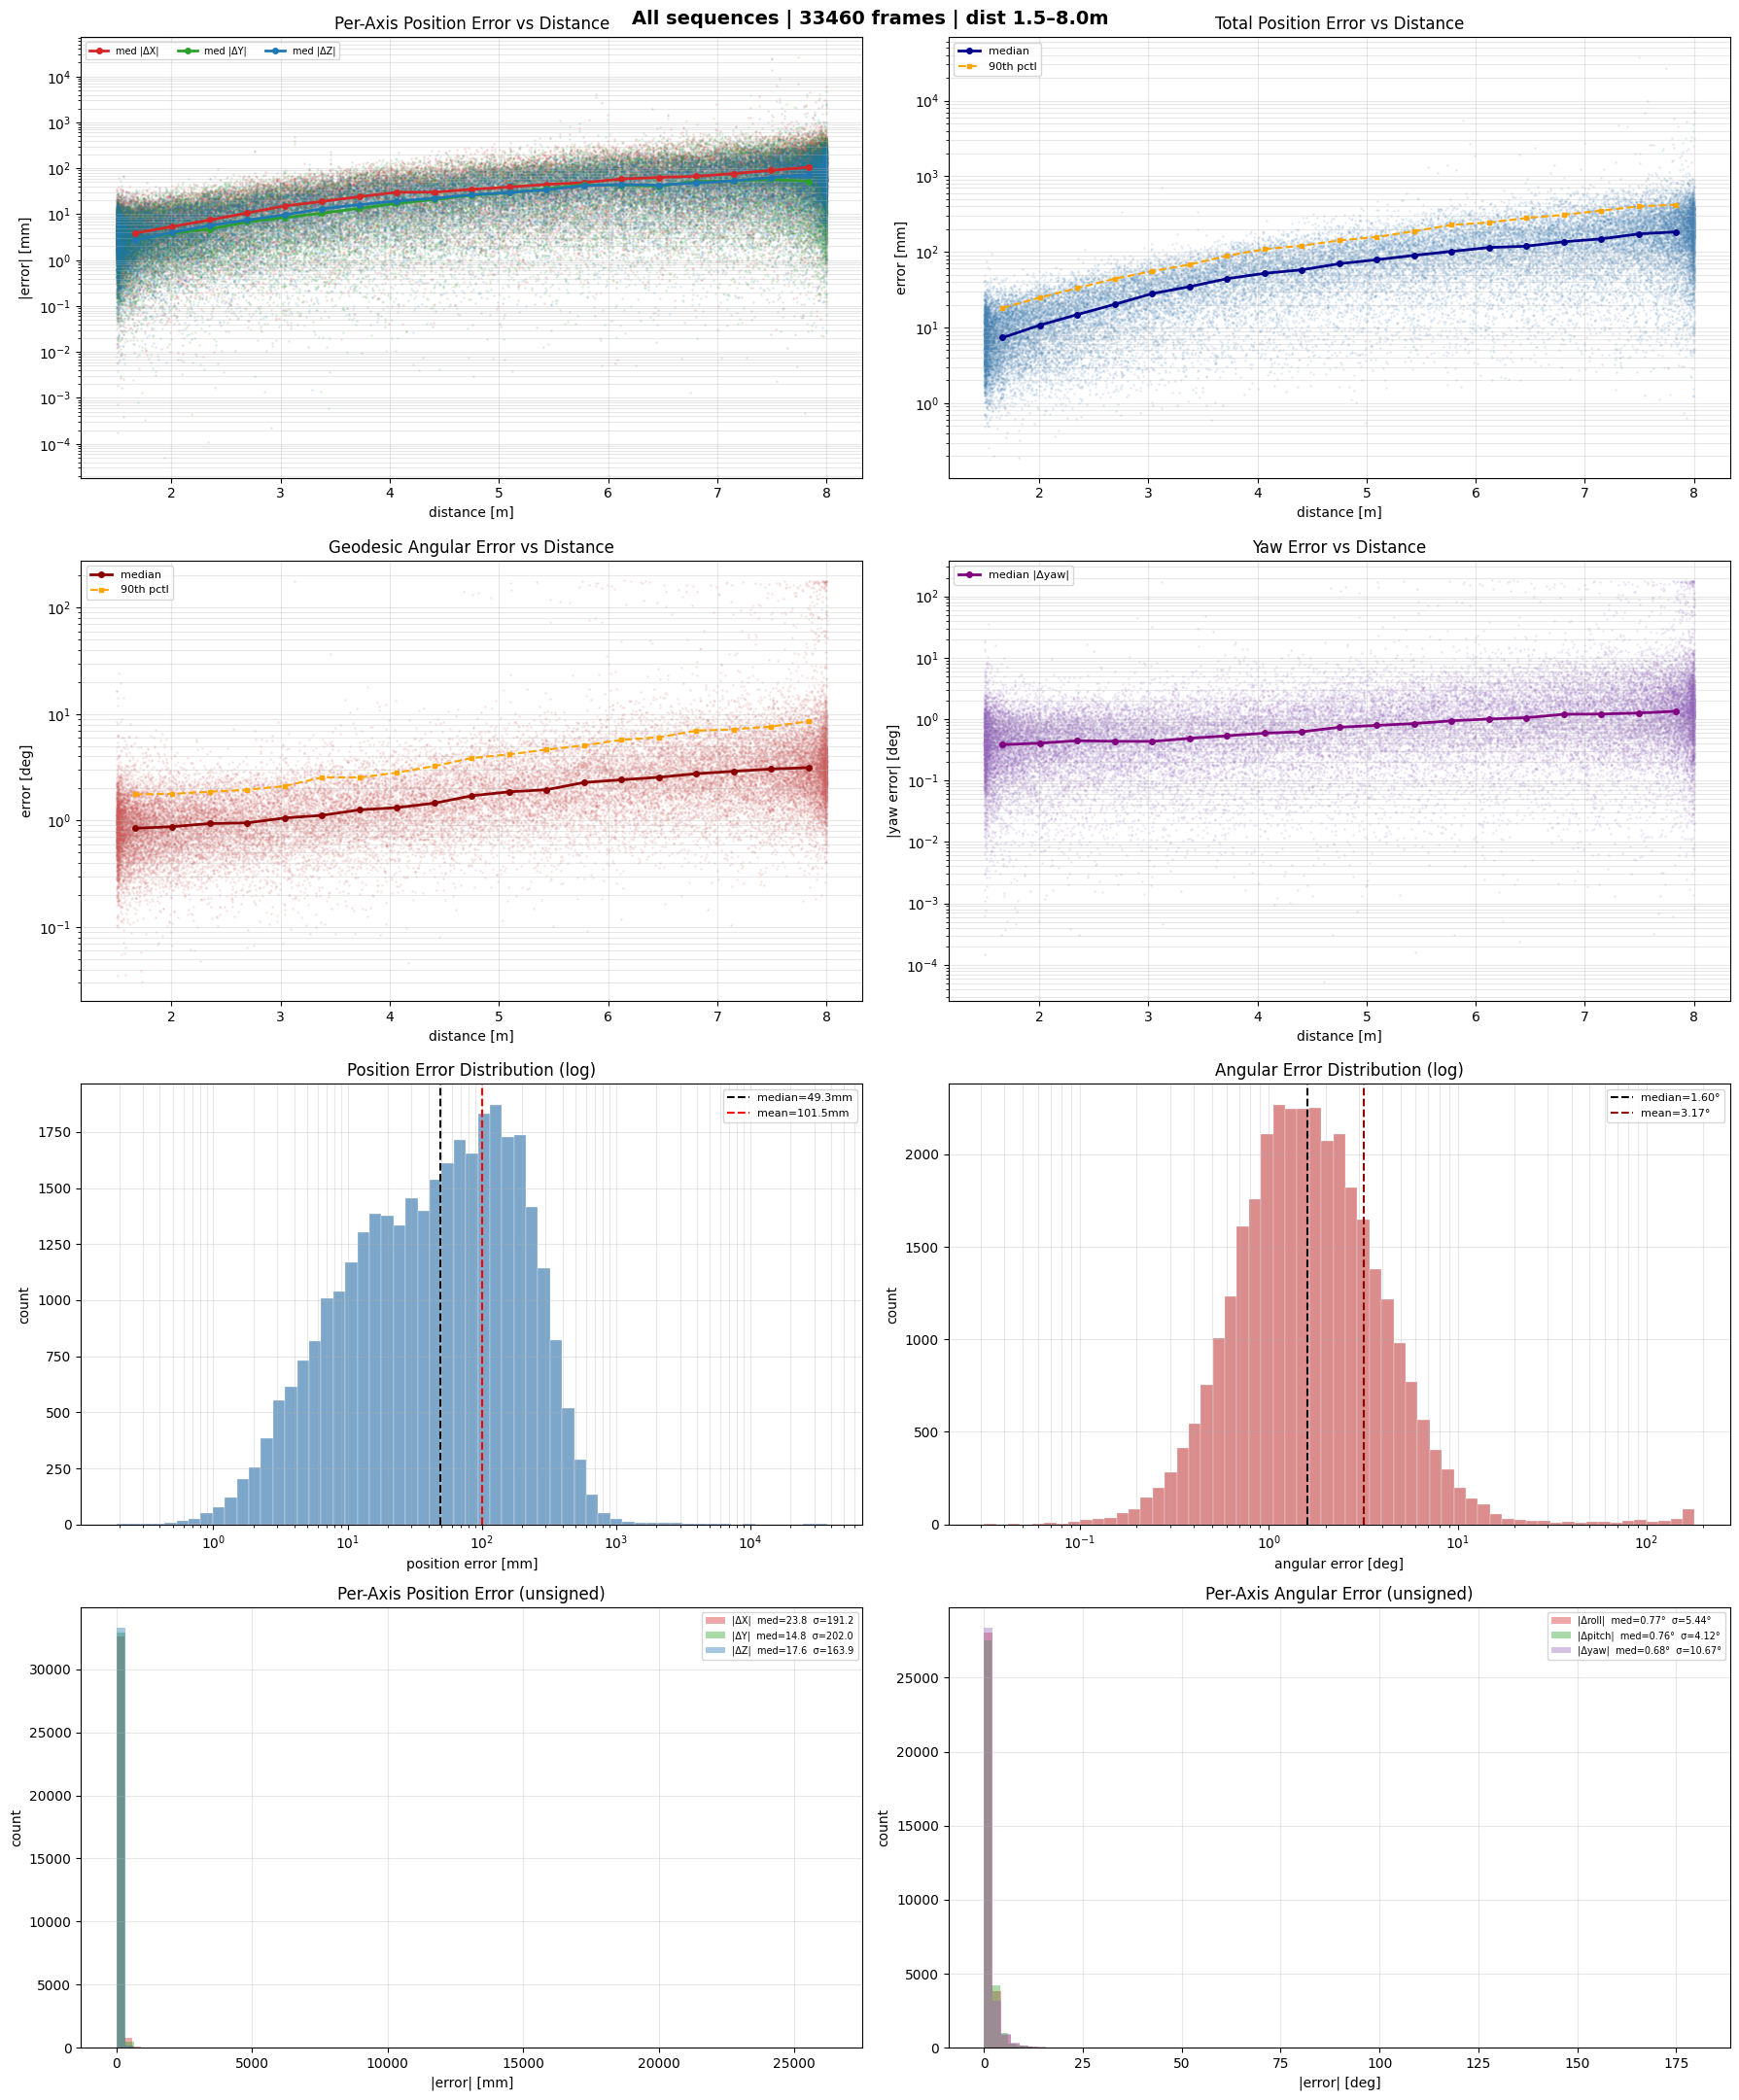

In [28]:
# YOLO6D PnP — AGGREGATE ERROR vs DISTANCE (LOG SCALE, flying)
#
# PURPOSE:
#   Concatenate all 140 flying sequences, plot position and orientation
#   error vs camera-to-target distance on log axes, plus error distributions.
#
# SUBPLOTS (4×2):
#   (0,0) Per-axis |Δx|,|Δy|,|Δz| vs distance + binned medians [mm]
#   (0,1) Total ||Δpos|| vs distance + median + 90th percentile [mm]
#   (1,0) Geodesic angular error vs distance + median + 90th pctl [deg]
#   (1,1) |Δyaw| vs distance + median [deg]
#   (2,0) Position error histogram (log-spaced bins) + mean/median
#   (2,1) Angular error histogram (log-spaced bins) + mean/median
#   (3,0) Per-axis position error histograms (linear, signed Δx/Δy/Δz) [mm]
#   (3,1) Yaw error histogram (linear, signed) [deg]
#
# INPUT:
#   pnp_results.json — 140 seq × ~240 frames, ~33600 total
#
# OUTPUT:
#   Single inline figure + console stats (mean/median pos mm, ang deg).

import json, numpy as np, matplotlib.pyplot as plt

path = "/home/michal/Desktop/rl_tracking/examples/deep_eagle/estimation_data/unreal/flying/pnp_results.json"
with open(path) as f:
    data = json.load(f)

# Concatenate all sequences
all_gt_pos, all_pnp_pos, all_gt_q, all_pnp_q, all_cam_pos, all_level = [], [], [], [], [], []

for seq_key in sorted(data.keys(), key=int):
    e = data[seq_key]
    gt_pos = np.array(e["pos"])
    pnp_pos = np.array(e["pnp_pos"])
    gt_q = np.array(e["quat"])
    pnp_q = np.array(e["pnp_q"])
    cam_pos = np.array(e["cam_pos"])
    ok = ~np.any(np.isnan(pnp_pos), axis=1)
    if not ok.any():
        continue
    all_gt_pos.append(gt_pos[ok]);  all_pnp_pos.append(pnp_pos[ok])
    all_gt_q.append(gt_q[ok]);     all_pnp_q.append(pnp_q[ok])
    all_cam_pos.append(cam_pos[ok]); all_level.append(np.full(ok.sum(), e["level"]))

gt_pos = np.concatenate(all_gt_pos);   pnp_pos = np.concatenate(all_pnp_pos)
gt_q = np.concatenate(all_gt_q);       pnp_q = np.concatenate(all_pnp_q)
cam_pos = np.concatenate(all_cam_pos);  levels = np.concatenate(all_level)
distance = np.linalg.norm(cam_pos - gt_pos, axis=1)

pos_err_xyz = (pnp_pos - gt_pos) * 1000  # mm
pos_err_norm = np.linalg.norm(pos_err_xyz, axis=1)

def quat_to_rpy(q):
    x, y, z, w = q[:,0], q[:,1], q[:,2], q[:,3]
    n = np.sqrt(x*x+y*y+z*z+w*w); n = np.where(n>0, n, 1.)
    x, y, z, w = x/n, y/n, z/n, w/n
    roll  = np.arctan2(2*(w*x+y*z), 1-2*(x*x+y*y))
    pitch = np.arcsin(np.clip(2*(w*y-z*x), -1, 1))
    yaw   = np.arctan2(2*(w*z+x*y), 1-2*(y*y+z*z))
    return np.rad2deg(np.stack([roll, pitch, yaw], axis=1))

gt_rpy = quat_to_rpy(gt_q);  pnp_rpy = quat_to_rpy(pnp_q)
rpy_err = (pnp_rpy - gt_rpy + 180) % 360 - 180
dot = np.sum(pnp_q * gt_q, axis=1)
ang_err = np.rad2deg(2 * np.arccos(np.clip(np.abs(dot), 0, 1)))

# Binning
bins = np.linspace(distance.min(), distance.max(), 20)
bin_c = 0.5 * (bins[:-1] + bins[1:])
idx = np.digitize(distance, bins)
valid_bins = [b for b in range(1, len(bins)) if (idx == b).sum() > 0]
bc = [bin_c[b-1] for b in valid_bins]

print(f"Total: {len(distance)} frames | dist {distance.min():.2f}–{distance.max():.2f}m")
print(f"Pos err: mean={pos_err_norm.mean():.1f}mm  median={np.median(pos_err_norm):.1f}mm")
print(f"Ang err: mean={ang_err.mean():.2f}°  median={np.median(ang_err):.2f}°")
print(f"Per-axis pos err (mm):  Δx={np.std(pos_err_xyz[:,0]):.1f}  Δy={np.std(pos_err_xyz[:,1]):.1f}  Δz={np.std(pos_err_xyz[:,2]):.1f}")
print(f"Yaw err: mean={np.mean(np.abs(rpy_err[:,2])):.2f}°  std={np.std(rpy_err[:,2]):.2f}°")

C = ["tab:red", "tab:green", "tab:blue"]
XYZ = ["X", "Y", "Z"]

fig, axes = plt.subplots(4, 2, figsize=(18, 22))

# ── (0,0) Per-axis position error vs distance ──
ax = axes[0, 0]
for i in range(3):
    ax.scatter(distance, np.abs(pos_err_xyz[:, i]), s=1, alpha=0.1, color=C[i])
    med = [np.median(np.abs(pos_err_xyz[idx == b, i])) for b in valid_bins]
    ax.plot(bc, med, "-o", color=C[i], lw=2, ms=4, label=f"med |Δ{XYZ[i]}|")
ax.set_yscale("log"); ax.set_xlabel("distance [m]"); ax.set_ylabel("|error| [mm]")
ax.set_title("Per-Axis Position Error vs Distance"); ax.legend(ncol=3, fontsize=7); ax.grid(True, alpha=0.3, which="both")

# ── (0,1) Total position error vs distance ──
ax = axes[0, 1]
ax.scatter(distance, pos_err_norm, s=1, alpha=0.1, color="steelblue")
med = [np.median(pos_err_norm[idx == b]) for b in valid_bins]
p90 = [np.percentile(pos_err_norm[idx == b], 90) for b in valid_bins]
ax.plot(bc, med, "-o", color="darkblue", lw=2, ms=4, label="median")
ax.plot(bc, p90, "--s", color="orange", lw=1.5, ms=3, label="90th pctl")
ax.set_yscale("log"); ax.set_xlabel("distance [m]"); ax.set_ylabel("error [mm]")
ax.set_title("Total Position Error vs Distance"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which="both")

# ── (1,0) Angular error vs distance ──
ax = axes[1, 0]
ax.scatter(distance, ang_err, s=1, alpha=0.1, color="indianred")
med = [np.median(ang_err[idx == b]) for b in valid_bins]
p90 = [np.percentile(ang_err[idx == b], 90) for b in valid_bins]
ax.plot(bc, med, "-o", color="darkred", lw=2, ms=4, label="median")
ax.plot(bc, p90, "--s", color="orange", lw=1.5, ms=3, label="90th pctl")
ax.set_yscale("log"); ax.set_xlabel("distance [m]"); ax.set_ylabel("error [deg]")
ax.set_title("Geodesic Angular Error vs Distance"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which="both")

# ── (1,1) Yaw error vs distance ──
ax = axes[1, 1]
ax.scatter(distance, np.abs(rpy_err[:, 2]), s=1, alpha=0.1, color="tab:purple")
med = [np.median(np.abs(rpy_err[idx == b, 2])) for b in valid_bins]
ax.plot(bc, med, "-o", color="purple", lw=2, ms=4, label="median |Δyaw|")
ax.set_yscale("log"); ax.set_xlabel("distance [m]"); ax.set_ylabel("|yaw error| [deg]")
ax.set_title("Yaw Error vs Distance"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which="both")

# ── (2,0) Position error distribution (log) ──
ax = axes[2, 0]
ax.hist(pos_err_norm, bins=np.logspace(np.log10(max(pos_err_norm.min(), 0.1)), np.log10(pos_err_norm.max()), 60),
        color="steelblue", alpha=0.7, edgecolor="white", lw=0.3)
ax.axvline(np.median(pos_err_norm), color="k", ls="--", lw=1.5, label=f"median={np.median(pos_err_norm):.1f}mm")
ax.axvline(np.mean(pos_err_norm), color="r", ls="--", lw=1.5, label=f"mean={np.mean(pos_err_norm):.1f}mm")
ax.set_xscale("log"); ax.set_xlabel("position error [mm]"); ax.set_ylabel("count")
ax.set_title("Position Error Distribution (log)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which="both")

# ── (2,1) Angular error distribution (log) ──
ax = axes[2, 1]
ax.hist(ang_err, bins=np.logspace(np.log10(max(ang_err.min(), 0.01)), np.log10(ang_err.max()), 60),
        color="indianred", alpha=0.7, edgecolor="white", lw=0.3)
ax.axvline(np.median(ang_err), color="k", ls="--", lw=1.5, label=f"median={np.median(ang_err):.2f}°")
ax.axvline(np.mean(ang_err), color="darkred", ls="--", lw=1.5, label=f"mean={np.mean(ang_err):.2f}°")
ax.set_xscale("log"); ax.set_xlabel("angular error [deg]"); ax.set_ylabel("count")
ax.set_title("Angular Error Distribution (log)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which="both")

# ── (3,0) Per-axis position error histograms (unsigned, log count) ──
ax = axes[3, 0]
nbins = 80
for i in range(3):
    ax.hist(np.abs(pos_err_xyz[:, i]), bins=nbins, color=C[i], alpha=0.4, edgecolor="none",
            label=f"|Δ{XYZ[i]}|  med={np.median(np.abs(pos_err_xyz[:,i])):.1f}  σ={np.std(pos_err_xyz[:,i]):.1f}")
ax.set_xlabel("|error| [mm]"); ax.set_ylabel("count")
ax.set_title("Per-Axis Position Error (unsigned)"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3, which="both")

# ── (3,1) Per-axis angular error histograms (unsigned, log count) ──
ax = axes[3, 1]
RPY_lbl = ["roll", "pitch", "yaw"]
RPY_C = ["tab:red", "tab:green", "tab:purple"]
for i in range(3):
    ax.hist(np.abs(rpy_err[:, i]), bins=nbins, color=RPY_C[i], alpha=0.4, edgecolor="none",
            label=f"|Δ{RPY_lbl[i]}|  med={np.median(np.abs(rpy_err[:,i])):.2f}°  σ={np.std(rpy_err[:,i]):.2f}°")
#ax.set_yscale("log"); 
ax.set_xlabel("|error| [deg]"); ax.set_ylabel("count")
ax.set_title("Per-Axis Angular Error (unsigned)"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3, which="both")

fig.suptitle(f"All sequences | {len(distance)} frames | dist {distance.min():.1f}–{distance.max():.1f}m",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [29]:
# SPLIT flying PnP RESULTS → TRAIN/TEST (stratified by arena × level)
#
# PURPOSE:
#   Split 140 sequences into 70 train + 70 test, keeping 5/10 per
#   (arena, level) combination. Save as separate JSONs.
#
# OUTPUT:
#   flying_dataset/train.json  (70 sequences)
#   flying_dataset/test.json   (70 sequences)
#   Console: split table per (arena, level)

import json, os, random
import numpy as np

SRC = "/home/michal/Desktop/rl_tracking/examples/deep_eagle/estimation_data/unreal/flying/pnp_results.json"
OUT_DIR = "/home/michal/Desktop/rl_tracking/examples/deep_eagle/estimation_data/unreal/flying_dataset"

with open(SRC) as f:
    data = json.load(f)

# Group keys by (arena, level)
groups = {}
for k, v in data.items():
    key = (v["arena"], v["level"])
    groups.setdefault(key, []).append(k)

# Verify structure
print(f"Total: {len(data)} sequences")
print(f"Groups: {len(groups)} (arena × level)")
print(f"\n{'arena':>5}  {'level':>5}  {'count':>5}")
print("-" * 20)
for (arena, level) in sorted(groups.keys()):
    print(f"±{arena:>4}  {level:>5}  {len(groups[(arena, level)]):>5}")

# Stratified split: 5 train + 5 test per group
random.seed(42)
train_keys, test_keys = [], []

for (arena, level) in sorted(groups.keys()):
    keys = sorted(groups[(arena, level)], key=int)
    assert len(keys) == 10, f"Expected 10 for arena={arena} level={level}, got {len(keys)}"
    random.shuffle(keys)
    train_keys.extend(keys[:5])
    test_keys.extend(keys[5:])

train_data = {k: data[k] for k in sorted(train_keys, key=int)}
test_data = {k: data[k] for k in sorted(test_keys, key=int)}

# Verify balance
print(f"\nTrain: {len(train_data)}  Test: {len(test_data)}")
print(f"\n{'arena':>5}  {'level':>5}  {'train':>5}  {'test':>5}")
print("-" * 25)
for (arena, level) in sorted(groups.keys()):
    n_tr = sum(1 for k in train_keys if data[k]["arena"] == arena and data[k]["level"] == level)
    n_te = sum(1 for k in test_keys if data[k]["arena"] == arena and data[k]["level"] == level)
    print(f"±{arena:>4}  {level:>5}  {n_tr:>5}  {n_te:>5}")

# Save
os.makedirs(OUT_DIR, exist_ok=True)
with open(os.path.join(OUT_DIR, "train.json"), "w") as f:
    json.dump(train_data, f)
with open(os.path.join(OUT_DIR, "test.json"), "w") as f:
    json.dump(test_data, f)

print(f"\nSaved to {OUT_DIR}/")
print(f"  train.json: {len(train_data)} sequences ({os.path.getsize(os.path.join(OUT_DIR, 'train.json')) / 1e6:.1f} MB)")
print(f"  test.json:  {len(test_data)} sequences ({os.path.getsize(os.path.join(OUT_DIR, 'test.json')) / 1e6:.1f} MB)")

Total: 140 sequences
Groups: 14 (arena × level)

arena  level  count
--------------------
±   5      3     10
±   5      6     10
±   5      9     10
±   5     12     10
±   5     15     10
±   5     18     10
±   5     21     10
±  15      3     10
±  15      6     10
±  15      9     10
±  15     12     10
±  15     15     10
±  15     18     10
±  15     21     10

Train: 70  Test: 70

arena  level  train   test
-------------------------
±   5      3      5      5
±   5      6      5      5
±   5      9      5      5
±   5     12      5      5
±   5     15      5      5
±   5     18      5      5
±   5     21      5      5
±  15      3      5      5
±  15      6      5      5
±  15      9      5      5
±  15     12      5      5
±  15     15      5      5
±  15     18      5      5
±  15     21      5      5

Saved to /home/michal/Desktop/rl_tracking/examples/deep_eagle/estimation_data/unreal/flying_dataset/
  train.json: 70 sequences (13.9 MB)
  test.json:  70 sequences (13.9 MB)


1. KEY INTEGRITY
  Original: 140  Train: 70  Test: 70
  Overlap:  0  ✓ NONE
  Missing:  0  ✓ NONE
  Extra:    0  ✓ NONE

2. DATA IDENTITY — values match original
  Checked 140 sequences × all fields: ✓ ALL MATCH

3. STRATIFICATION
  arena  level  train   test    ok
  ------------------------------
  ±   5      3      5      5     ✓
  ±   5      6      5      5     ✓
  ±   5      9      5      5     ✓
  ±   5     12      5      5     ✓
  ±   5     15      5      5     ✓
  ±   5     18      5      5     ✓
  ±   5     21      5      5     ✓
  ±  15      3      5      5     ✓
  ±  15      6      5      5     ✓
  ±  15      9      5      5     ✓
  ±  15     12      5      5     ✓
  ±  15     15      5      5     ✓
  ±  15     18      5      5     ✓
  ±  15     21      5      5     ✓
  ✓ BALANCED

4. FIELD SHAPES + NaN AUDIT
  Shape errors: 0  ✓
  NaN in GT:    0  ✓
  PnP coverage: 33460/33460 (100.0%)

5. CENTRAL DIFFERENCE CONSISTENCY (all 140 sequences)
  CD(pos)→vel  RMS: mean=0.003103  

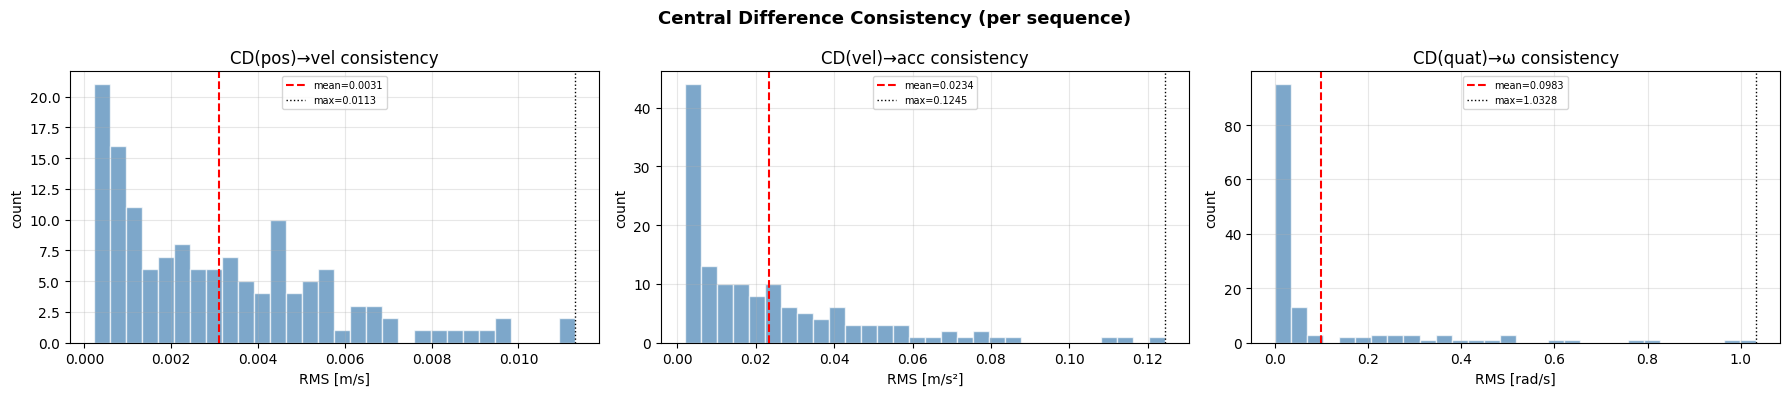


6. VISUAL CHECK — 200 random frames
  Sampled 200 valid PnP frames


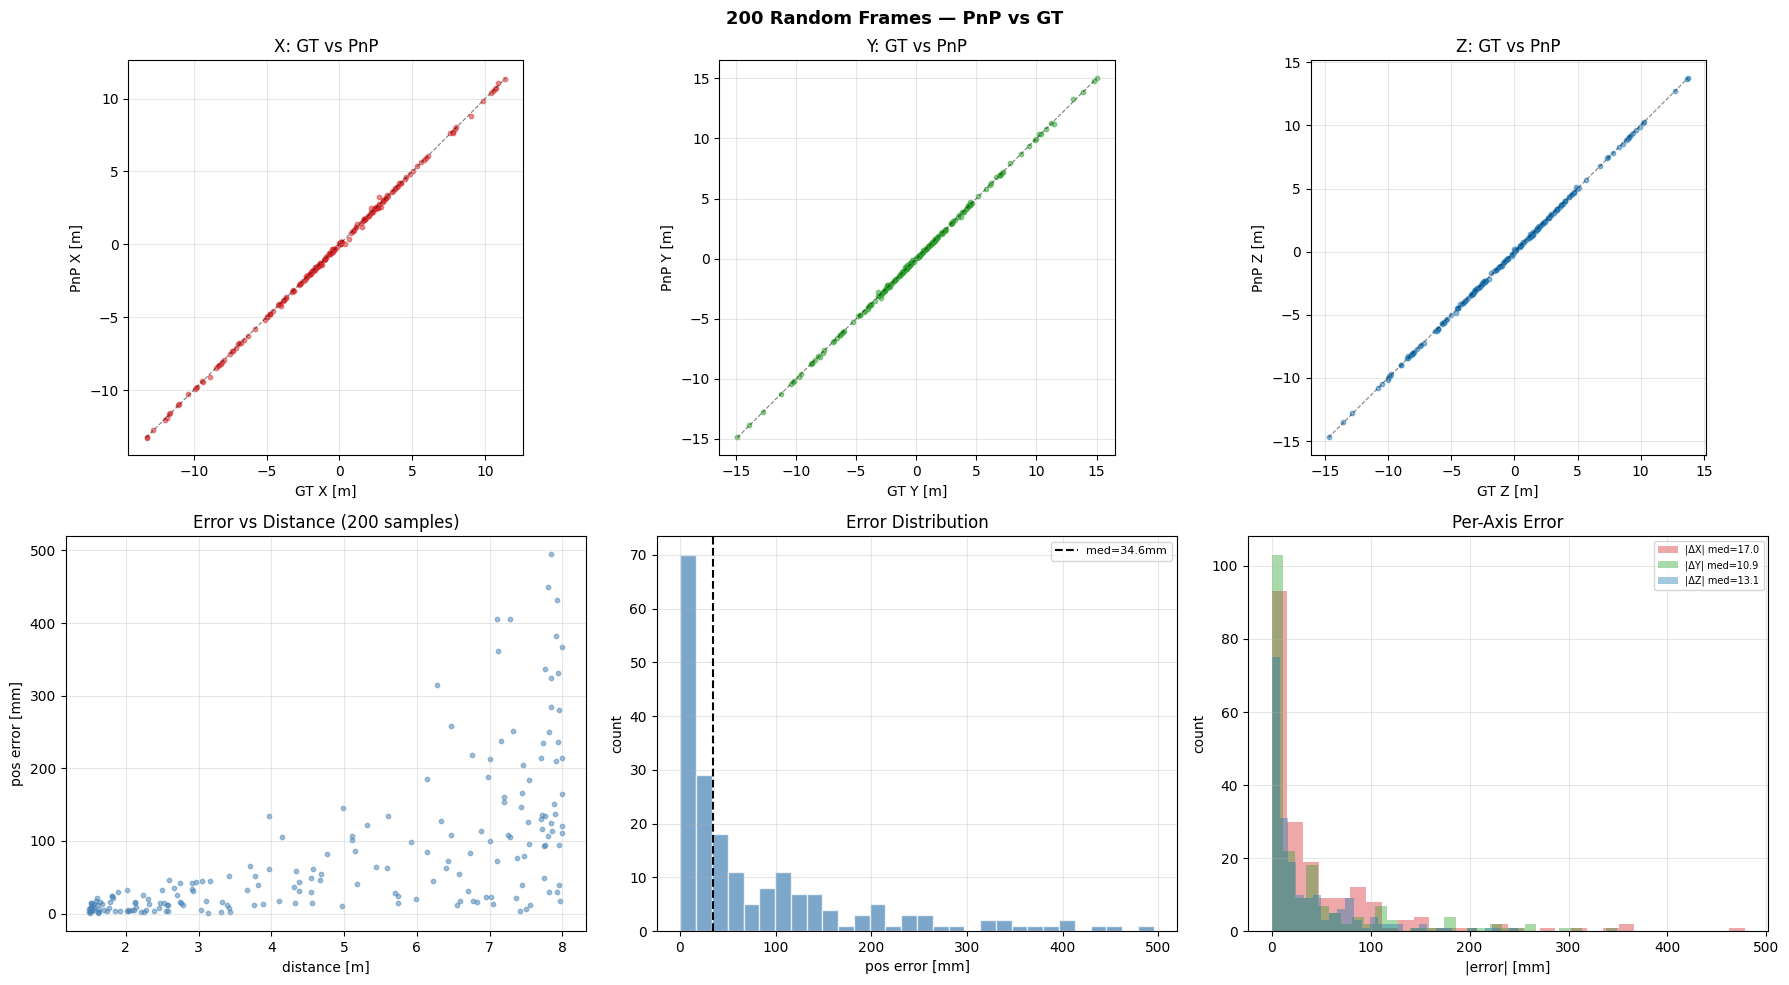

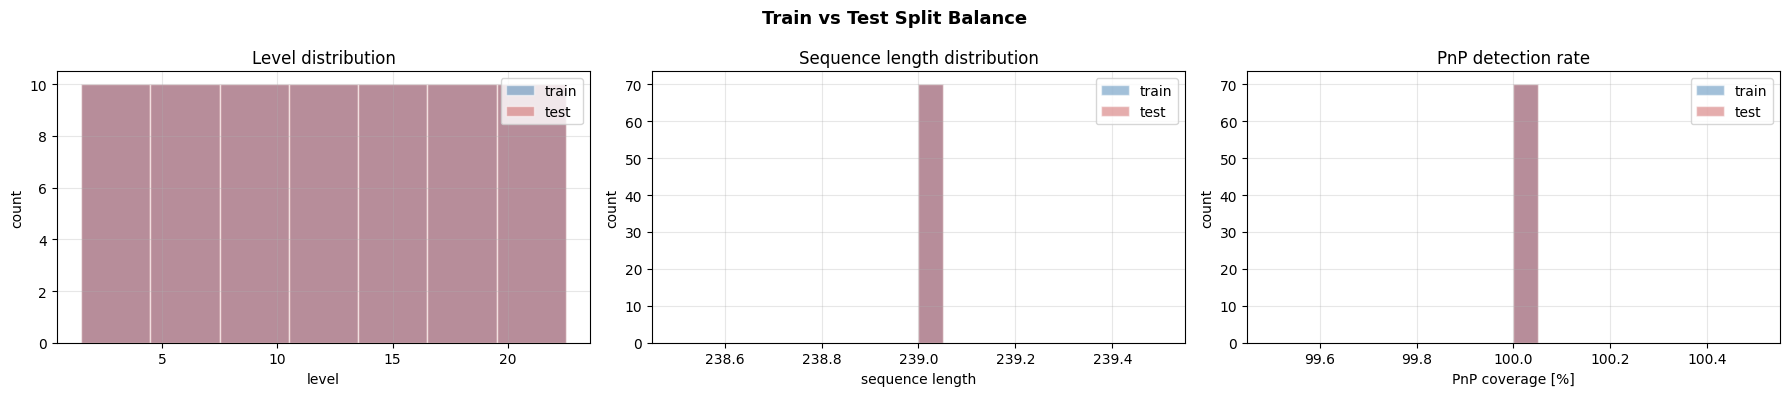


ALL CHECKS COMPLETE
  66: level=12 arena=±5 ω_RMS=0.588
  100: level=18 arena=±5 ω_RMS=0.972
  120: level=21 arena=±5 ω_RMS=0.648
  121: level=21 arena=±5 ω_RMS=0.824
  122: level=21 arena=±5 ω_RMS=0.776
  129: level=21 arena=±5 ω_RMS=0.507
  130: level=21 arena=±15 ω_RMS=1.033


In [31]:
# FLYING DATASET VALIDATION — TRAIN/TEST COHERENCE CHECK
#
# PURPOSE:
#   Thorough validation of train.json + test.json before shipping.
#   Checks: key integrity, no overlap, stratification balance,
#   GT derivative chain consistency (CD), PnP coverage, NaN audit.
#   200 random frames plotted for visual sanity.
#
# CHECKS:
#   1. No key overlap between train/test
#   2. Union = original pnp_results.json
#   3. Stratification: 5/5 per (arena, level)
#   4. Field shapes: all arrays same length as t
#   5. No unexpected NaNs in GT fields (pos, quat, vel, acc, omega, cam_pos, cam_q)
#   6. CD(pos)≈vel, CD(vel)≈acc, CD(quat)→ω≈omega_b — RMS per sequence
#   7. PnP coverage stats
#
# OUTPUT:
#   Console report + 3 summary figures

import json, numpy as np, matplotlib.pyplot as plt, random

BASE = "/home/michal/Desktop/rl_tracking/examples/deep_eagle/estimation_data/unreal/flying"
ORIG = f"{BASE}/pnp_results.json"
TRAIN = f"{BASE}_dataset/train.json"
TEST = f"{BASE}_dataset/test.json"

with open(ORIG) as f:
    orig = json.load(f)
with open(TRAIN) as f:
    train = json.load(f)
with open(TEST) as f:
    test = json.load(f)

print("=" * 70)
print("1. KEY INTEGRITY")
print("=" * 70)
train_keys = set(train.keys())
test_keys = set(test.keys())
orig_keys = set(orig.keys())

overlap = train_keys & test_keys
missing = orig_keys - (train_keys | test_keys)
extra = (train_keys | test_keys) - orig_keys

print(f"  Original: {len(orig_keys)}  Train: {len(train_keys)}  Test: {len(test_keys)}")
print(f"  Overlap:  {len(overlap)}  {'✓ NONE' if not overlap else '✗ OVERLAP: ' + str(overlap)}")
print(f"  Missing:  {len(missing)}  {'✓ NONE' if not missing else '✗ MISSING: ' + str(missing)}")
print(f"  Extra:    {len(extra)}  {'✓ NONE' if not extra else '✗ EXTRA: ' + str(extra)}")
assert not overlap, "TRAIN/TEST OVERLAP!"
assert not missing, "KEYS MISSING FROM SPLIT!"
assert not extra, "EXTRA KEYS IN SPLIT!"

print("\n" + "=" * 70)
print("2. DATA IDENTITY — values match original")
print("=" * 70)
mismatch = 0
for split_name, split_data in [("train", train), ("test", test)]:
    for k in split_data:
        for field in orig[k]:
            if orig[k][field] != split_data[k][field]:
                print(f"  ✗ {split_name}[{k}][{field}] differs from original!")
                mismatch += 1
print(f"  Checked {len(train) + len(test)} sequences × all fields: {'✓ ALL MATCH' if mismatch == 0 else f'✗ {mismatch} MISMATCHES'}")

print("\n" + "=" * 70)
print("3. STRATIFICATION")
print("=" * 70)
print(f"  {'arena':>5}  {'level':>5}  {'train':>5}  {'test':>5}  {'ok':>4}")
print("  " + "-" * 30)
strat_ok = True
for arena in sorted(set(v["arena"] for v in orig.values())):
    for level in sorted(set(v["level"] for v in orig.values())):
        n_tr = sum(1 for v in train.values() if v["arena"] == arena and v["level"] == level)
        n_te = sum(1 for v in test.values() if v["arena"] == arena and v["level"] == level)
        ok = "✓" if n_tr == 5 and n_te == 5 else "✗"
        if ok == "✗":
            strat_ok = False
        print(f"  ±{arena:>4}  {level:>5}  {n_tr:>5}  {n_te:>5}  {ok:>4}")
print(f"  {'✓ BALANCED' if strat_ok else '✗ IMBALANCED'}")

print("\n" + "=" * 70)
print("4. FIELD SHAPES + NaN AUDIT")
print("=" * 70)
GT_FIELDS_3 = ["pos", "quat", "rts_vel", "fd_vel", "rts_acc", "fd_acc", "omega_b", "cam_pos", "cam_q"]
shape_errors = 0
nan_errors = 0
all_data = {**train, **test}

for k in sorted(all_data.keys(), key=int):
    e = all_data[k]
    N = len(e["t"])
    for field in GT_FIELDS_3:
        if field not in e:
            continue
        arr = np.array(e[field])
        expected_cols = 4 if field in ("quat", "cam_q") else 3
        if arr.shape != (N, expected_cols):
            print(f"  ✗ [{k}] {field}: shape {arr.shape} != ({N},{expected_cols})")
            shape_errors += 1
        if np.any(np.isnan(arr)):
            print(f"  ✗ [{k}] {field}: has NaN!")
            nan_errors += 1

# PnP fields CAN have NaN — just report coverage
pnp_ok_total = 0
pnp_total = 0
for k, e in all_data.items():
    N = len(e["t"])
    pnp_total += N
    pnp_ok_total += sum(1 for p in e["pnp_pos"] if not any(np.isnan(p)))

print(f"  Shape errors: {shape_errors}  {'✓' if shape_errors == 0 else '✗'}")
print(f"  NaN in GT:    {nan_errors}  {'✓' if nan_errors == 0 else '✗'}")
print(f"  PnP coverage: {pnp_ok_total}/{pnp_total} ({100*pnp_ok_total/pnp_total:.1f}%)")

print("\n" + "=" * 70)
print("5. CENTRAL DIFFERENCE CONSISTENCY (all 140 sequences)")
print("=" * 70)

def cd2(x, dt):
    a = np.zeros_like(x)
    a[1:-1] = (x[2:] - x[:-2]) / (2 * dt)
    a[0]    = (-3*x[0] + 4*x[1] - x[2]) / (2 * dt)
    a[-1]   = (3*x[-1] - 4*x[-2] + x[-3]) / (2 * dt)
    return a

def quat_mul(a, b):
    ax, ay, az, aw = a[:,0], a[:,1], a[:,2], a[:,3]
    bx, by, bz, bw = b[:,0], b[:,1], b[:,2], b[:,3]
    return np.column_stack([
        aw*bx + ax*bw + ay*bz - az*by,
        aw*by - ax*bz + ay*bw + az*bx,
        aw*bz + ax*by - ay*bx + az*bw,
        aw*bw - ax*bx - ay*by - az*bz,
    ])

rms_vel, rms_acc, rms_omega = [], [], []
seq_keys_all = sorted(all_data.keys(), key=int)

for k in seq_keys_all:
    e = all_data[k]
    t = np.array(e["t"])
    dt = t[1] - t[0]
    pos = np.array(e["pos"])
    vel = np.array(e.get("rts_vel", e.get("fd_vel")))
    acc = np.array(e.get("rts_acc", e.get("fd_acc")))
    quat = np.array(e["quat"])
    omega = np.array(e["omega_b"])

    # pos→vel
    vel_cd = cd2(pos, dt)
    rms_v = np.sqrt(np.mean((vel_cd - vel)**2))
    rms_vel.append(rms_v)

    # vel→acc
    acc_cd = cd2(vel, dt)
    rms_a = np.sqrt(np.mean((acc_cd - acc)**2))
    rms_acc.append(rms_a)

    # quat→omega
    q_conj = quat.copy(); q_conj[:, :3] *= -1
    q_dot = cd2(quat, dt)
    omega_cd = 2 * quat_mul(q_conj, q_dot)[:, :3]
    rms_w = np.sqrt(np.mean((omega_cd - omega)**2))
    rms_omega.append(rms_w)

rms_vel = np.array(rms_vel)
rms_acc = np.array(rms_acc)
rms_omega = np.array(rms_omega)

print(f"  CD(pos)→vel  RMS: mean={rms_vel.mean():.6f}  max={rms_vel.max():.6f} m/s")
print(f"  CD(vel)→acc  RMS: mean={rms_acc.mean():.6f}  max={rms_acc.max():.6f} m/s²")
print(f"  CD(quat)→ω   RMS: mean={rms_omega.mean():.6f}  max={rms_omega.max():.6f} rad/s")

VEL_THRESH = 0.01
ACC_THRESH = 0.5   # CD at boundaries can be noisy
OMG_THRESH = 0.5
bad_vel = np.sum(rms_vel > VEL_THRESH)
bad_acc = np.sum(rms_acc > ACC_THRESH)
bad_omg = np.sum(rms_omega > OMG_THRESH)
print(f"  Outliers: vel>{VEL_THRESH}: {bad_vel}  acc>{ACC_THRESH}: {bad_acc}  ω>{OMG_THRESH}: {bad_omg}")

# ── FIGURE 1: RMS distributions ──
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, vals, name, unit in zip(axes,
    [rms_vel, rms_acc, rms_omega],
    ["CD(pos)→vel", "CD(vel)→acc", "CD(quat)→ω"],
    ["m/s", "m/s²", "rad/s"]):
    ax.hist(vals, bins=30, color="steelblue", alpha=0.7, edgecolor="white")
    ax.axvline(vals.mean(), color="r", ls="--", lw=1.5, label=f"mean={vals.mean():.4f}")
    ax.axvline(vals.max(), color="k", ls=":", lw=1, label=f"max={vals.max():.4f}")
    ax.set_xlabel(f"RMS [{unit}]"); ax.set_ylabel("count")
    ax.set_title(f"{name} consistency"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
fig.suptitle("Central Difference Consistency (per sequence)", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

# ── FIGURE 2: 200 random frames — PnP vs GT pos scatter ──
print("\n" + "=" * 70)
print("6. VISUAL CHECK — 200 random frames")
print("=" * 70)

random.seed(123)
sample_frames = []
for k in all_data:
    e = all_data[k]
    pnp_pos = np.array(e["pnp_pos"])
    gt_pos = np.array(e["pos"])
    cam_pos = np.array(e["cam_pos"])
    ok = ~np.any(np.isnan(pnp_pos), axis=1)
    for i in np.where(ok)[0]:
        sample_frames.append((gt_pos[i], pnp_pos[i], cam_pos[i], e["level"], e["arena"], k))

random.shuffle(sample_frames)
sample_frames = sample_frames[:200]
print(f"  Sampled {len(sample_frames)} valid PnP frames")

gt = np.array([s[0] for s in sample_frames])
pnp = np.array([s[1] for s in sample_frames])
cam = np.array([s[2] for s in sample_frames])
dist = np.linalg.norm(cam - gt, axis=1)
err = np.linalg.norm(pnp - gt, axis=1) * 1000

C = ["tab:red", "tab:green", "tab:blue"]
XYZ = ["X", "Y", "Z"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 0: GT vs PnP per axis
for i in range(3):
    ax = axes[0, i]
    ax.scatter(gt[:, i], pnp[:, i], s=10, alpha=0.5, color=C[i])
    lims = [min(gt[:, i].min(), pnp[:, i].min()), max(gt[:, i].max(), pnp[:, i].max())]
    ax.plot(lims, lims, "k--", lw=0.8, alpha=0.5)
    ax.set_xlabel(f"GT {XYZ[i]} [m]"); ax.set_ylabel(f"PnP {XYZ[i]} [m]")
    ax.set_title(f"{XYZ[i]}: GT vs PnP"); ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

# Row 1: error vs distance, error histogram, per-axis error histogram
ax = axes[1, 0]
ax.scatter(dist, err, s=10, alpha=0.5, color="steelblue")
ax.set_xlabel("distance [m]"); ax.set_ylabel("pos error [mm]")
ax.set_title("Error vs Distance (200 samples)"); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.hist(err, bins=30, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(np.median(err), color="k", ls="--", lw=1.5, label=f"med={np.median(err):.1f}mm")
ax.set_xlabel("pos error [mm]"); ax.set_ylabel("count")
ax.set_title("Error Distribution"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
for i in range(3):
    ax.hist(np.abs(pnp[:, i] - gt[:, i]) * 1000, bins=30, color=C[i], alpha=0.4,
            label=f"|Δ{XYZ[i]}| med={np.median(np.abs(pnp[:,i]-gt[:,i])*1000):.1f}")
ax.set_xlabel("|error| [mm]"); ax.set_ylabel("count")
ax.set_title("Per-Axis Error"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

fig.suptitle("200 Random Frames — PnP vs GT", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

# ── FIGURE 3: Train vs Test distribution sanity ──
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, split_name, split_data, color in [
    (axes[0], "train", train, "steelblue"),
    (axes[0], "test", test, "indianred"),
]:
    levels = [v["level"] for v in split_data.values()]
    ax.hist(levels, bins=np.arange(1.5, 23, 3), alpha=0.5, color=color, edgecolor="white", label=split_name)
axes[0].set_xlabel("level"); axes[0].set_ylabel("count")
axes[0].set_title("Level distribution"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

for ax, split_name, split_data, color in [
    (axes[1], "train", train, "steelblue"),
    (axes[1], "test", test, "indianred"),
]:
    lengths = [len(v["t"]) for v in split_data.values()]
    ax.hist(lengths, bins=20, alpha=0.5, color=color, edgecolor="white", label=split_name)
axes[1].set_xlabel("sequence length"); axes[1].set_ylabel("count")
axes[1].set_title("Sequence length distribution"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

for ax, split_name, split_data, color in [
    (axes[2], "train", train, "steelblue"),
    (axes[2], "test", test, "indianred"),
]:
    coverages = []
    for v in split_data.values():
        N = len(v["t"])
        nok = sum(1 for p in v["pnp_pos"] if not any(np.isnan(p)))
        coverages.append(100 * nok / N)
    ax.hist(coverages, bins=20, alpha=0.5, color=color, edgecolor="white", label=split_name)
axes[2].set_xlabel("PnP coverage [%]"); axes[2].set_ylabel("count")
axes[2].set_title("PnP detection rate"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

fig.suptitle("Train vs Test Split Balance", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

print("\n" + "=" * 70)
print("ALL CHECKS COMPLETE")
print("=" * 70)

# Which sequences have high omega RMS?
for i, k in enumerate(seq_keys_all):
    if rms_omega[i] > 0.5:
        e = all_data[k]
        print(f"  {k}: level={e['level']} arena=±{e['arena']} ω_RMS={rms_omega[i]:.3f}")